# Task 2 Model Experimentation and Development - Global AI & Data Jobs Salary Dataset

## Objective

The purpose of this modelling task is to develop and evaluate a machine learning regression pipeline using PyCaret to predict the annual base salary of AI and data-related jobs.

The primary target variable is `salary_usd`. The modelling process will include preprocessing and transformation, model comparison using k-fold cross-validation, hyperparameter tuning, evaluation using multiple regression performance metrics, and selection of the best-performing model.

MLflow will also be used to track model experiments, metrics and artifacts throughout the model development process.

| Section | Purpose |
|---|---|
| **1. Modelling Preparation** | Validate data quality, identify the target and features to exclude, and reserve a separate unseen dataset before model development. |
| **2. Experiment 1 - Baseline Models** | Establish a baseline by training and comparing multiple regression models using the original non-leakage feature set with 10-fold cross-validation. |
| **3. Experiment 2 - Feature Selection and Engineering** | Evaluate EDA-guided feature refinement by removing redundant or weakly informative predictors and creating an engineered employment stability feature. |
| **4. Experiment 3 - Normalisation and Target Transformation** | Evaluate whether Min-Max normalisation and target transformation improve model performance while retaining the original feature configuration. |
| **5. Experiment 4 - Feature Refinement with Preprocessing** | Evaluate whether the feature-refined dataset performs better when combined with normalisation and target transformation. |
| **6. Experiment Comparison and Model Selection** | Compare the strongest models across all experiments using consistent cross-validation metrics and select the best modelling configuration. |
| **7. Hyperparameter Tuning** | Tune the selected CatBoost model, identify the best hyperparameter values, and compare its performance before and after tuning. |
| **8. Holdout Evaluation** | Evaluate the tuned model on the independent PyCaret holdout set using multiple regression metrics and diagnostic plots. |
| **9. Final Model Training** | Retrain the selected tuned model using the complete development dataset through PyCaret's `finalize_model()` function. |
| **10. Final Prediction on Unseen Data** | Apply the finalised pipeline to the separately reserved unseen dataset and evaluate its final predictive performance. |
| **11. Save Final Pipeline and Processed Dataset** | Save the complete preprocessing and CatBoost pipeline together with the transformed development dataset for reuse and versioning. |
| **12. MLflow Model Registration** | Register the final model in MLflow to maintain a versioned record for model lifecycle management and future deployment. |

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from hydra import compose, initialize

PROJECT_ROOT = Path.cwd().parents[1]

with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="config")

raw_data_path = PROJECT_ROOT / cfg.data.raw_path

df = pd.read_csv(raw_data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (90000, 35)


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


## 1. Modelling Preparation

The target variable for this regression task is `salary_usd`.

Before modelling, `id` is excluded because it is only a unique identifier. Based on the EDA and feature definitions, `bonus_usd` and `salary_percentile` are also excluded as potential target-leakage features, since they may contain salary-related information that would not be independently available when predicting a new job record.

All remaining predictors are initially retained, including features with weak individual relationships with salary, as they may still contribute through non-linear relationships or interactions.

The EDA also identified several preprocessing considerations. `experience_level` has a clear ordinal structure, while the treatment of `education_required` and `company_size` will be defined during preprocessing. Since most numerical predictors do not show substantial skewness, numerical feature transformation will not be applied by default.

A separate experiment will evaluate a transformed `salary_usd` target because the target distribution showed moderate positive skewness.

### 1.1 Data Quality Validation

Data quality findings from the EDA are verified before model development. Missing values, duplicate records and invalid target values are checked to ensure that the dataset supplied to the modelling pipeline is suitable for training.

Potential target-leakage and identifier variables are handled separately during feature preparation. Valid extreme salary observations are retained as they represent legitimate values rather than confirmed data errors.

In [44]:
# Validate data quality before modelling
data_quality = pd.DataFrame({
    "Check": [
        "Missing values",
        "Duplicate rows",
        "Duplicate IDs",
        "Non-positive salary values"
    ],
    "Count": [
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["id"].duplicated().sum(),
        (df["salary_usd"] <= 0).sum()
    ]
})

data_quality

,Check,Count
0,Missing values,0
1,Duplicate rows,0
2,Duplicate IDs,0
3,Non-positive salary values,0


### 1.2 Reserve Unseen Data

Before model experimentation, 10% of the original dataset is randomly reserved as unseen data using a fixed random state for reproducibility. This produces **81,000 records for model development** and **9,000 records for final unseen prediction**.

The reserved unseen data will not be used during preprocessing experimentation, model comparison, cross-validation, hyperparameter tuning, or model selection. This ensures that it remains independent from the model development process and can be used to assess the final selected pipeline on previously unseen records.

The remaining 90% of the dataset is used for model development. PyCaret will subsequently perform an 80/20 train-holdout split on this development dataset, while 10-fold cross-validation is performed using the training portion.

In [2]:
from sklearn.model_selection import train_test_split

model_data, unseen_data = train_test_split(
    df,
    test_size=0.10,
    random_state=cfg.model.random_state
)

target = cfg.model.target

# Features excluded due to identifier / potential target leakage
ignore_features = [
    "salary_percentile",
    "bonus_usd",
    "id"
]

print(f"Target variable: {target}")
print(f"Features excluded from modelling: {ignore_features}")
print(f"Original dataset shape: {df.shape}")
print("Model development data:", model_data.shape)
print("Reserved unseen data:", unseen_data.shape)

Target variable: salary_usd
Features excluded from modelling: ['salary_percentile', 'bonus_usd', 'id']
Original dataset shape: (90000, 35)
Model development data: (81000, 35)
Reserved unseen data: (9000, 35)


## 2. Experiment 1 - Baseline Models with All Non-Leakage Candidate Features

The first experiment establishes a baseline using all remaining candidate predictors after excluding `id` and the potential target-leakage features `bonus_usd` and `salary_percentile`.

Basic preprocessing required to represent the data appropriately is applied. Based on the feature definitions identified during EDA, `experience_level`, `education_required`, and `company_size` are treated as ordinal categorical features using explicitly defined category orderings. The remaining categorical variables are handled using PyCaret's standard categorical preprocessing.

The original `salary_usd` target is used without target transformation, automated feature selection, additional feature engineering, or optional numerical transformation. This provides a controlled baseline against which subsequent modelling experiments can be compared.

Later experiments will investigate techniques such as feature selection, feature engineering, alternative preprocessing strategies, and target transformation.

In [3]:
import os
import mlflow

os.environ["GIT_PYTHON_REFRESH"] = "quiet" # does not complain about GIT login 
mlflow.set_tracking_uri("http://127.0.0.1:5000")


### 2.1 Initialise Baseline PyCaret Experiment

The baseline PyCaret regression experiment is initialised using an 80/20 train-holdout split with 10-fold cross-validation.

`id`, `bonus_usd`, and `salary_percentile` are excluded, while all remaining candidate predictors are retained. Based on the EDA, `experience_level`, `education_required`, and `company_size` are treated as ordinal features using predefined category orderings, while PyCaret handles the remaining categorical preprocessing automatically.

During 10-fold cross-validation, the training data is divided into 10 subsets. The model is trained on 9 folds and validated on the remaining fold, repeating this process until every fold has been used for validation. The average performance across the folds provides a more reliable estimate of model performance than relying on a single train-validation split.

No automated feature selection, feature engineering, numerical transformation, or target transformation is applied in this baseline experiment. A fixed random state ensures reproducibility, while MLflow is enabled to track experiment results.

In [4]:
from pycaret.regression import RegressionExperiment

ordinal_features = {
    "experience_level": [
        "Entry",
        "Mid",
        "Senior",
        "Lead"
    ],

    "education_required": [
        "Bootcamp",
        "Diploma",
        "Bachelor",
        "Master",
        "PhD"
    ],

    "company_size": [
        "Startup",
        "Small",
        "Medium",
        "Large",
        "Enterprise"
    ]
}

categorical_features = [
    "country",
    "job_role",
    "ai_specialization",
    "industry",
    "work_mode"
]

baseline_exp = RegressionExperiment()

baseline_exp.setup(
    data=model_data,
    target=target,
    ignore_features=ignore_features,
    ordinal_features=ordinal_features,
    categorical_features=categorical_features,
    train_size=1 - cfg.training.test_size,
    fold_strategy="kfold",
    fold=cfg.training.fold,
    fold_shuffle=True,
    session_id=cfg.model.random_state,
    log_experiment="mlflow",
    experiment_name="salary_baseline_non_leakage"
)

,Description,Value
0,Session id,42
1,Target,salary_usd
2,Target type,Regression
3,Original data shape,"(81000, 35)"
4,Transformed data shape,"(81000, 68)"
5,Transformed train set shape,"(64800, 68)"
6,Transformed test set shape,"(16200, 68)"
7,Ignore features,3
8,Ordinal features,3
9,Numeric features,23


2026/08/21 11:42:44 INFO mlflow.tracking.fluent: Experiment with name 'salary_baseline_non_leakage' does not exist. Creating a new experiment.


### 2.2 Baseline Model Comparison

Multiple regression algorithms are trained and evaluated using the same preprocessing pipeline and 10-fold cross-validation strategy defined in the baseline experiment.

The models are compared using MAE, MSE, RMSE, R², RMSLE, and MAPE. Among these metrics, `RMSE` is used as the primary metric for model comparison because it measures prediction error in the same USD scale as `salary_usd` while penalising larger errors more heavily than MAE. This is useful for salary prediction because the target contains legitimate high-salary observations, where large prediction errors would be particularly undesirable.

The remaining metrics are still considered to provide a broader assessment of model performance. MAE provides a more robust view of typical absolute error, while R² indicates the proportion of salary variation explained by the model.

The top-performing models are retained as candidates for subsequent modelling experiments and later hyperparameter tuning.

In [5]:
baseline_models = baseline_exp.compare_models(
    n_select=3,
    sort="RMSE"
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,8880.5998,127908206.2225,11309.1373,0.9336,0.1092,0.0939,3.4610
gbr,Gradient Boosting Regressor,9218.4935,138638974.4099,11773.7290,0.9280,0.1184,0.0998,2.5010
rf,Random Forest Regressor,9205.0585,139850610.6207,11825.2763,0.9274,0.1130,0.0965,13.2960
et,Extra Trees Regressor,9388.3710,145472684.3690,12060.1925,0.9245,0.1159,0.0985,9.8330
lasso,Lasso Regression,11290.6555,207984150.8876,14421.4032,0.8920,0.2935,0.1433,1.3660
llar,Lasso Least Angle Regression,11290.6419,207984158.7269,14421.4035,0.8920,0.2935,0.1433,0.1760
br,Bayesian Ridge,11290.8968,207990344.0211,14421.6183,0.8920,0.2943,0.1433,0.3920
ridge,Ridge Regression,11291.2089,207990379.2421,14421.6195,0.8920,0.2937,0.1433,0.1750
lr,Linear Regression,13118.4152,311704135.6751,16510.8955,0.8386,0.3236,0.1668,0.7540
dt,Decision Tree Regressor,12342.3258,275360719.3922,16593.3799,0.8571,0.1580,0.1285,0.3710


2026/08/21 11:49:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 11:49:23 INFO mlflow.tracking._tracking_service.client: 🏃 View run CatBoost Regressor at: http://127.0.0.1:5000/#/experiments/563889065327885322/runs/661c8cd0125d4f36808e80e61078612b.
2026/08/21 11:49:23 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/563889065327885322.
2026/08/21 11:49:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 11:49:46 INFO mlflow.tracking._tracking_service.client: 🏃 View run Gradient Boosting Regressor at: http://127.0.0.1:5000/#/experiments/563889065327885322/runs/27b94084830c47ccb49c5cb8a8506e2f.
2026/08/21 11:49:46 INFO mlflow.tracking._tracking_service.clien

### 2.3 Baseline Model Comparison Results

#### Performance Metric Summary

The regression models are evaluated using several complementary performance metrics:

- **MAE (Mean Absolute Error)** - Measures the average absolute difference between the actual and predicted salary values. It is expressed in USD, making it easy to interpret. **Lower values are better.**

- **MSE (Mean Squared Error)** - Measures the average squared prediction error. Squaring the errors gives larger mistakes a much greater penalty. **Lower values are better**, although the squared units make it less directly interpretable.

- **RMSE (Root Mean Squared Error)** - The square root of MSE, returning the error to the original USD scale. It penalises larger prediction errors more heavily than MAE and is used as the **primary model-selection metric** in this project. **Lower values are better.**

- **R² (Coefficient of Determination)** - Measures how much of the variation in `salary_usd` is explained by the model. For example, an R² of 0.93 indicates that approximately 93% of the variation in salary is explained by the model. **Higher values are better**, with 1 representing a perfect fit.

- **RMSLE (Root Mean Squared Logarithmic Error)** - Measures prediction error on a logarithmic scale and focuses more on proportional differences between actual and predicted values. **Lower values are better.**

- **MAPE (Mean Absolute Percentage Error)** - Measures the average prediction error as a proportion of the actual value. For example, a MAPE of 0.10 corresponds to an average absolute percentage error of approximately 10%. **Lower values are better.**

In [6]:
baseline_results = baseline_exp.pull()

baseline_results.style.format({
    "MAE": "{:,.2f}",
    "MSE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R2": "{:.4f}",
    "RMSLE": "{:.4f}",
    "MAPE": "{:.4f}",
    "TT (Sec)": "{:.3f}"
})

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,"8,880.60","127,908,206.22","11,309.14",0.9336,0.1092,0.0939,3.461
gbr,Gradient Boosting Regressor,"9,218.49","138,638,974.41","11,773.73",0.9280,0.1184,0.0998,2.501
rf,Random Forest Regressor,"9,205.06","139,850,610.62","11,825.28",0.9274,0.1130,0.0965,13.296
et,Extra Trees Regressor,"9,388.37","145,472,684.37","12,060.19",0.9245,0.1159,0.0985,9.833
lasso,Lasso Regression,"11,290.66","207,984,150.89","14,421.40",0.8920,0.2935,0.1433,1.366
llar,Lasso Least Angle Regression,"11,290.64","207,984,158.73","14,421.40",0.8920,0.2935,0.1433,0.176
br,Bayesian Ridge,"11,290.90","207,990,344.02","14,421.62",0.8920,0.2943,0.1433,0.392
ridge,Ridge Regression,"11,291.21","207,990,379.24","14,421.62",0.8920,0.2937,0.1433,0.175
lr,Linear Regression,"13,118.42","311,704,135.68","16,510.90",0.8386,0.3236,0.1668,0.754
dt,Decision Tree Regressor,"12,342.33","275,360,719.39","16,593.38",0.8571,0.1580,0.1285,0.371


The baseline comparison shows that ensemble tree-based models perform best under 10-fold cross-validation. CatBoost achieved the lowest RMSE of approximately **$11,309.14**, the lowest MAE of **$8,880.60**, and the highest R² of **0.9336**, making it the strongest baseline model according to the primary ranking metric.

Gradient Boosting ranked second with an RMSE of approximately **$11,773.73** and R² of **0.9280**, while Random Forest ranked third with an RMSE of **$11,825.28** and R² of **0.9274**.

These ensemble models substantially outperform the regularised linear models, which achieved RMSE values of approximately **$14,421** and R² values of around **0.8920**. This suggests that non-linear relationships and interactions between predictors provide useful information for salary prediction.

CatBoost, Gradient Boosting, and Random Forest will be retained as the strongest baseline candidates for comparison with the subsequent modelling experiments.

## 3. Experiment 2 - EDA-Guided Feature Selection and Feature Engineering

The second experiment evaluates whether reducing redundant or weakly informative predictors and combining closely related features can improve model performance.

Based on the EDA, `job_security_score` and `layoff_risk` are strongly related and represent similar aspects of employment stability. These two variables are replaced with a single engineered `employment_stability_score` to reduce redundancy while preserving their underlying information. In addition, `work_life_balance_score` (EDA 6.2) and `year` (EDA 7.3) are removed because the EDA suggested limited additional contribution relative to related predictors.

The remaining predictors are retained, including variables with weak individual correlations, as they may still contribute through non-linear relationships or interactions.

The same train-holdout split, 10-fold cross-validation strategy, preprocessing approach, and original `salary_usd` target are retained so that the effect of these feature refinements can be compared fairly against the baseline experiment.

The `employment_stability_score` combines `job_security_score` with the inverse of `layoff_risk` so that both components follow the same direction, where a higher value represents greater employment stability.

For example, if a job has a `job_security_score` of **80** and a `layoff_risk` of **0.20**, the layoff risk is first inverted and converted to a 0-100 scale:

`(1 - 0.20) × 100 = 80`

The two values are then averaged:

`(80 + 80) / 2 = 80`

The resulting `employment_stability_score` is **80**.

In [7]:
# Create Experiment 2 dataset
feature_data = model_data.copy()

# Engineer a combined employment stability feature
feature_data["employment_stability_score"] = (
    feature_data["job_security_score"]
    + (1 - feature_data["layoff_risk"]) * 100
) / 2

# Features removed based on EDA findings
manual_removed_features = [
    "job_security_score",
    "layoff_risk",
    "work_life_balance_score",
    "year"
]

feature_data.drop(
    columns=manual_removed_features,
    inplace=True
)

print("Baseline excluded features:", ignore_features)
print("Additional removed features:", manual_removed_features)
print("Engineered feature: employment_stability_score")
print("Experiment 2 dataset shape:", feature_data.shape)

Baseline excluded features: ['salary_percentile', 'bonus_usd', 'id']
Additional removed features: ['job_security_score', 'layoff_risk', 'work_life_balance_score', 'year']
Engineered feature: employment_stability_score
Experiment 2 dataset shape: (81000, 32)


### 3.1 Initialise Feature Selection PyCaret Experiment

In [8]:
feature_selection_exp = RegressionExperiment()

feature_selection_exp.setup(
    data=feature_data,
    target=target,
    ignore_features=ignore_features,
    ordinal_features=ordinal_features,
    categorical_features=categorical_features,
    train_size=1 - cfg.training.test_size,
    fold_strategy="kfold",
    fold=cfg.training.fold,
    fold_shuffle=True,
    session_id=cfg.model.random_state,
    log_experiment="mlflow",
    experiment_name="salary_feature_selection"
)

,Description,Value
0,Session id,42
1,Target,salary_usd
2,Target type,Regression
3,Original data shape,"(81000, 32)"
4,Transformed data shape,"(81000, 65)"
5,Transformed train set shape,"(64800, 65)"
6,Transformed test set shape,"(16200, 65)"
7,Ignore features,3
8,Ordinal features,3
9,Numeric features,20


2026/08/21 11:50:54 INFO mlflow.tracking.fluent: Experiment with name 'salary_feature_selection' does not exist. Creating a new experiment.


### 3.2 Feature Selection Model Comparison

In [9]:
feature_selection_models = feature_selection_exp.compare_models(
    n_select=3,
    sort="RMSE"
)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,11:50:57
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,8904.7089,128354142.2176,11328.8870,0.9334,0.1094,0.0941,3.2770
gbr,Gradient Boosting Regressor,9240.7659,139447580.9370,11807.9382,0.9276,0.1184,0.0999,2.3580
rf,Random Forest Regressor,9216.8252,140289909.4335,11843.7447,0.9272,0.1132,0.0966,11.6370
et,Extra Trees Regressor,9421.9575,146682969.5863,12110.3371,0.9239,0.1163,0.0988,9.1100
llar,Lasso Least Angle Regression,11342.8829,209669993.1795,14479.6630,0.8912,0.2933,0.1440,0.1450
lasso,Lasso Regression,11342.9016,209670010.8938,14479.6636,0.8912,0.2933,0.1440,1.1320
ridge,Ridge Regression,11343.4252,209672641.3530,14479.7539,0.8912,0.2924,0.1440,0.1440
br,Bayesian Ridge,11343.1378,209672686.8229,14479.7554,0.8912,0.2929,0.1440,0.3460
dt,Decision Tree Regressor,12332.6233,274777661.1655,16575.6363,0.8574,0.1577,0.1284,0.3490
lr,Linear Regression,13687.9583,345340963.6553,17377.5212,0.8209,0.3266,0.1744,0.2560


2026/08/21 11:56:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 11:56:49 INFO mlflow.tracking._tracking_service.client: 🏃 View run CatBoost Regressor at: http://127.0.0.1:5000/#/experiments/343861897017226918/runs/d75468554d084aff9a247d7cddf2d893.
2026/08/21 11:56:49 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/343861897017226918.
2026/08/21 11:57:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 11:57:11 INFO mlflow.tracking._tracking_service.client: 🏃 View run Gradient Boosting Regressor at: http://127.0.0.1:5000/#/experiments/343861897017226918/runs/b03e51c3c9d34a89bcd60e7d0a1c33f2.
2026/08/21 11:57:11 INFO mlflow.tracking._tracking_service.clien

### 3.3 Feature Selection and Engineering Model Comparison Results

The feature-refined experiment produced similar performance to the baseline, with CatBoost, Gradient Boosting, and Random Forest remaining the three strongest models. CatBoost achieved the lowest RMSE of approximately **$11,328.89**, followed by Gradient Boosting at **$11,807.94** and Random Forest at **$11,843.74**.

However, all three models performed slightly worse than their corresponding baseline results. CatBoost's RMSE increased from **$11,309.14 to $11,328.89**, Gradient Boosting from **$11,773.73 to $11,807.94**, and Random Forest from **$11,825.28 to $11,843.74**. Their MAE and R² values also showed small deteriorations.

This suggests that replacing `job_security_score` and `layoff_risk` with the engineered `employment_stability_score`, together with removing `work_life_balance_score` and `year`, resulted in a small loss of predictive information when used without additional preprocessing.

For **Experiment 3**, the original baseline feature configuration is restored so that the effect of normalisation and target transformation can be evaluated independently. The feature-refined configuration will subsequently be combined with these preprocessing techniques in Experiment 4 to assess whether the two approaches perform better when used together.

In [10]:
feature_selection_results = feature_selection_exp.pull()

feature_selection_results.style.format({
    "MAE": "{:,.2f}",
    "MSE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R2": "{:.4f}",
    "RMSLE": "{:.4f}",
    "MAPE": "{:.4f}",
    "TT (Sec)": "{:.3f}"
})

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,"8,904.71","128,354,142.22","11,328.89",0.9334,0.1094,0.0941,3.277
gbr,Gradient Boosting Regressor,"9,240.77","139,447,580.94","11,807.94",0.9276,0.1184,0.0999,2.358
rf,Random Forest Regressor,"9,216.83","140,289,909.43","11,843.74",0.9272,0.1132,0.0966,11.637
et,Extra Trees Regressor,"9,421.96","146,682,969.59","12,110.34",0.9239,0.1163,0.0988,9.110
llar,Lasso Least Angle Regression,"11,342.88","209,669,993.18","14,479.66",0.8912,0.2933,0.1440,0.145
lasso,Lasso Regression,"11,342.90","209,670,010.89","14,479.66",0.8912,0.2933,0.1440,1.132
ridge,Ridge Regression,"11,343.43","209,672,641.35","14,479.75",0.8912,0.2924,0.1440,0.144
br,Bayesian Ridge,"11,343.14","209,672,686.82","14,479.76",0.8912,0.2929,0.1440,0.346
dt,Decision Tree Regressor,"12,332.62","274,777,661.17","16,575.64",0.8574,0.1577,0.1284,0.349
lr,Linear Regression,"13,687.96","345,340,963.66","17,377.52",0.8209,0.3266,0.1744,0.256


## 4. Experiment 3 - Normalisation and Target Transformation

The third experiment evaluates whether additional preprocessing can improve model performance. Since Experiment 2 produced slightly weaker results, the original baseline feature configuration from Experiment 1 is restored.

Min-Max normalisation is applied to the numerical predictors to place them on a common scale. Although the EDA did not identify feature scaling as a specific requirement, normalisation is evaluated as an additional preprocessing step to determine whether scale-sensitive models benefit from having numerical variables represented on a consistent range.

In addition, transformation is applied to the `salary_usd` target because the EDA identified moderate positive skewness in its distribution. This transformation aims to reduce the skewness of the target and lessen the influence of very high salary values during model training.

The same train-holdout split, 10-fold cross-validation strategy, and random state are retained to ensure that the results can be compared fairly with the previous experiments.

### 4.1 Initialise Normalisation and Target Transformation PyCaret Experiment

In [11]:
preprocessing_exp = RegressionExperiment()

preprocessing_exp.setup(
    data=model_data,
    target=target,
    ignore_features=ignore_features,
    ordinal_features=ordinal_features,
    categorical_features=categorical_features,

    normalize=True,
    normalize_method="minmax",

    transform_target=True,

    train_size=1 - cfg.training.test_size,
    fold_strategy="kfold",
    fold=cfg.training.fold,
    fold_shuffle=True,
    session_id=cfg.model.random_state,

    log_experiment="mlflow",
    experiment_name="salary_normalization_target_transform"
)

,Description,Value
0,Session id,42
1,Target,salary_usd
2,Target type,Regression
3,Original data shape,"(81000, 35)"
4,Transformed data shape,"(81000, 68)"
5,Transformed train set shape,"(64800, 68)"
6,Transformed test set shape,"(16200, 68)"
7,Ignore features,3
8,Ordinal features,3
9,Numeric features,23


2026/08/21 11:59:36 INFO mlflow.tracking.fluent: Experiment with name 'salary_normalization_target_transform' does not exist. Creating a new experiment.


### 4.2 Normalisation and Target Transformation Model Comparison

In [12]:
preprocessing_models = preprocessing_exp.compare_models(
    n_select=3,
    sort="RMSE"
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,8849.0822,126895760.8850,11264.2506,0.9341,0.1082,0.0928,3.4100
huber,Huber Regressor,9140.8088,135713081.8359,11649.1262,0.9296,0.1181,0.0985,1.4360
br,Bayesian Ridge,9160.9611,136156230.4948,11668.0922,0.9293,0.1179,0.0984,0.4200
ridge,Ridge Regression,9161.1166,136166063.1361,11668.5130,0.9293,0.1179,0.0984,0.2100
gbr,Gradient Boosting Regressor,9082.3389,136187004.3563,11669.1567,0.9293,0.1119,0.0958,2.5570
lr,Linear Regression,9192.6719,137238028.3988,11714.0141,0.9288,0.1184,0.0988,0.3240
rf,Random Forest Regressor,9210.9539,139839419.5398,11824.7946,0.9274,0.1128,0.0961,12.4760
et,Extra Trees Regressor,9396.2112,145858261.2766,12076.1130,0.9243,0.1158,0.0981,9.5990
ada,AdaBoost Regressor,12121.1313,257192875.7587,16035.2836,0.8665,0.1638,0.1345,2.9020
par,Passive Aggressive Regressor,12260.3908,267494988.1816,16132.2089,0.8612,0.1641,0.1301,0.2380


2026/08/21 12:05:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:05:50 INFO mlflow.tracking._tracking_service.client: 🏃 View run CatBoost Regressor at: http://127.0.0.1:5000/#/experiments/651957420376816323/runs/02ef990abf524572b5bf1ff7db5efc27.
2026/08/21 12:05:50 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/651957420376816323.
2026/08/21 12:05:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:05:54 INFO mlflow.tracking._tracking_service.client: 🏃 View run Huber Regressor at: http://127.0.0.1:5000/#/experiments/651957420376816323/runs/bc09b1cde7af4747a9d9453bfafb6a1b.
2026/08/21 12:05:54 INFO mlflow.tracking._tracking_service.client: 🧪 View ex

### 4.3 Normalisation and Target Transformation Model Comparison Results

Under the normalisation and target-transformation configuration, CatBoost achieved the strongest performance with the lowest RMSE of approximately **$11,264.25**, the lowest MAE of **$8,849.08**, and the highest R² of **0.9341**.

Huber Regressor ranked second with an RMSE of approximately **$11,649.13** and R² of **0.9296**, while Bayesian Ridge ranked third with an RMSE of approximately **$11,668.09** and R² of **0.9293**.

The results show that the additional preprocessing improves the competitiveness of several models, particularly Huber Regressor and Bayesian Ridge, while CatBoost remains the strongest model under this configuration.

In [13]:
preprocessing_results = preprocessing_exp.pull()

preprocessing_results.style.format({
    "MAE": "{:,.2f}",
    "MSE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R2": "{:.4f}",
    "RMSLE": "{:.4f}",
    "MAPE": "{:.4f}",
    "TT (Sec)": "{:.3f}"
})

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,"8,849.08","126,895,760.89","11,264.25",0.9341,0.1082,0.0928,3.410
huber,Huber Regressor,"9,140.81","135,713,081.84","11,649.13",0.9296,0.1181,0.0985,1.436
br,Bayesian Ridge,"9,160.96","136,156,230.49","11,668.09",0.9293,0.1179,0.0984,0.420
ridge,Ridge Regression,"9,161.12","136,166,063.14","11,668.51",0.9293,0.1179,0.0984,0.210
gbr,Gradient Boosting Regressor,"9,082.34","136,187,004.36","11,669.16",0.9293,0.1119,0.0958,2.557
lr,Linear Regression,"9,192.67","137,238,028.40","11,714.01",0.9288,0.1184,0.0988,0.324
rf,Random Forest Regressor,"9,210.95","139,839,419.54","11,824.79",0.9274,0.1128,0.0961,12.476
et,Extra Trees Regressor,"9,396.21","145,858,261.28","12,076.11",0.9243,0.1158,0.0981,9.599
ada,AdaBoost Regressor,"12,121.13","257,192,875.76","16,035.28",0.8665,0.1638,0.1345,2.902
par,Passive Aggressive Regressor,"12,260.39","267,494,988.18","16,132.21",0.8612,0.1641,0.1301,0.238


## 5. Experiment 4 - Feature Refinement with Normalisation and Target Transformation

The fourth experiment evaluates whether the feature refinement introduced in Experiment 2 performs better when combined with the additional preprocessing techniques used in Experiment 3.

The feature-refined configuration is retained, where `job_security_score` and `layoff_risk` are replaced by the engineered `employment_stability_score`, while `work_life_balance_score` and `year` remain removed.

Min-Max normalisation is applied to the numerical predictors to place them on a common scale. Although the EDA did not identify feature scaling as a specific requirement, it is evaluated to determine whether scale-sensitive models benefit from a consistent numerical range.

Transformation is also applied to the `salary_usd` target because the EDA identified moderate positive skewness in its distribution. This aims to reduce target skewness and lessen the influence of very high salary values during training.

The same train-holdout split, 10-fold cross-validation strategy, and random state are retained to ensure a fair comparison with the previous experiments. This experiment assesses whether combining feature refinement with additional preprocessing produces better performance than applying either approach independently.

### 5.1 Initialise Feature Refinement with Normalisation and Target Transformation PyCaret Experiment

In [14]:
combined_exp = RegressionExperiment()

combined_exp.setup(
    # Using the experiment 2 dataset with feature refinement and engineered features
    data=feature_data,
    target=target,
    ignore_features=ignore_features,
    ordinal_features=ordinal_features,
    categorical_features=categorical_features,

    # Additional preprocessing from Experiment 3
    normalize=True,
    normalize_method="minmax",
    transform_target=True,

    train_size=1 - cfg.training.test_size,
    fold_strategy="kfold",
    fold=cfg.training.fold,
    fold_shuffle=True,
    session_id=cfg.model.random_state,

    log_experiment="mlflow",
    experiment_name="salary_feature_refinement_normalization_target_transform"
)

,Description,Value
0,Session id,42
1,Target,salary_usd
2,Target type,Regression
3,Original data shape,"(81000, 32)"
4,Transformed data shape,"(81000, 65)"
5,Transformed train set shape,"(64800, 65)"
6,Transformed test set shape,"(16200, 65)"
7,Ignore features,3
8,Ordinal features,3
9,Numeric features,20


2026/08/21 12:11:23 INFO mlflow.tracking.fluent: Experiment with name 'salary_feature_refinement_normalization_target_transform' does not exist. Creating a new experiment.


### 5.2 Feature Refinement with Normalisation and Target Transformation Model Comparison

In [15]:
combined_models = combined_exp.compare_models(
    n_select=3,
    sort="RMSE"
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,8879.4479,127807879.5364,11304.6195,0.9337,0.1084,0.0931,3.4070
gbr,Gradient Boosting Regressor,9109.7621,137058538.3414,11706.4462,0.9289,0.1121,0.0960,2.3830
huber,Huber Regressor,9197.0984,137320749.9136,11717.8215,0.9287,0.1186,0.0990,1.2320
br,Bayesian Ridge,9215.0178,137736192.8422,11735.4957,0.9285,0.1185,0.0990,0.3840
ridge,Ridge Regression,9215.1163,137746231.2244,11735.9230,0.9285,0.1185,0.0990,0.1810
lar,Least Angle Regression,9215.4910,137748708.3069,11736.0330,0.9285,0.1185,0.0990,0.1880
lr,Linear Regression,9224.8734,138072376.5775,11749.5918,0.9283,0.1187,0.0991,0.7580
rf,Random Forest Regressor,9220.8147,140245372.9054,11841.9723,0.9272,0.1128,0.0961,11.9650
et,Extra Trees Regressor,9424.4545,146875526.3373,12118.0864,0.9238,0.1162,0.0984,9.1060
ada,AdaBoost Regressor,12085.0017,255655963.4803,15986.7345,0.8673,0.1628,0.1335,2.7700


2026/08/21 12:18:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:18:10 INFO mlflow.tracking._tracking_service.client: 🏃 View run CatBoost Regressor at: http://127.0.0.1:5000/#/experiments/710598589307773645/runs/b8c92e0d625e481a8a8f8a874e79c8db.
2026/08/21 12:18:10 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/710598589307773645.
2026/08/21 12:18:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:18:32 INFO mlflow.tracking._tracking_service.client: 🏃 View run Gradient Boosting Regressor at: http://127.0.0.1:5000/#/experiments/710598589307773645/runs/76a81980e6c44c91945754658f9577cd.
2026/08/21 12:18:32 INFO mlflow.tracking._tracking_service.clien

### 5.3 Feature Refinement with Normalisation and Target Transformation Model Comparison Results

Under the combined feature-refinement and preprocessing configuration, CatBoost achieved the strongest performance with the lowest RMSE of approximately **$11,304.62**, the lowest MAE of **$8,879.45**, and the highest R² of **0.9337**.

Gradient Boosting ranked second with an RMSE of approximately **$11,706.45** and R² of **0.9289**, while Huber Regressor ranked third with an RMSE of approximately **$11,717.82** and R² of **0.9287**.

The results show that CatBoost remains the strongest model under this configuration, while both Gradient Boosting and Huber Regressor also achieve relatively competitive performance after combining feature refinement with normalisation and target transformation.

In [16]:
combined_results = combined_exp.pull()

combined_results.style.format({
    "MAE": "{:,.2f}",
    "MSE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R2": "{:.4f}",
    "RMSLE": "{:.4f}",
    "MAPE": "{:.4f}",
    "TT (Sec)": "{:.3f}"
})

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,"8,879.45","127,807,879.54","11,304.62",0.9337,0.1084,0.0931,3.407
gbr,Gradient Boosting Regressor,"9,109.76","137,058,538.34","11,706.45",0.9289,0.1121,0.0960,2.383
huber,Huber Regressor,"9,197.10","137,320,749.91","11,717.82",0.9287,0.1186,0.0990,1.232
br,Bayesian Ridge,"9,215.02","137,736,192.84","11,735.50",0.9285,0.1185,0.0990,0.384
ridge,Ridge Regression,"9,215.12","137,746,231.22","11,735.92",0.9285,0.1185,0.0990,0.181
lar,Least Angle Regression,"9,215.49","137,748,708.31","11,736.03",0.9285,0.1185,0.0990,0.188
lr,Linear Regression,"9,224.87","138,072,376.58","11,749.59",0.9283,0.1187,0.0991,0.758
rf,Random Forest Regressor,"9,220.81","140,245,372.91","11,841.97",0.9272,0.1128,0.0961,11.965
et,Extra Trees Regressor,"9,424.45","146,875,526.34","12,118.09",0.9238,0.1162,0.0984,9.106
ada,AdaBoost Regressor,"12,085.00","255,655,963.48","15,986.73",0.8673,0.1628,0.1335,2.770


## 6. Experiment Comparison and Selection of Final Modelling Setup

The top three models from each experiment are compared using the same evaluation metrics obtained from 10-fold cross-validation. RMSE remains the primary comparison metric, while MAE and R² are also considered when selecting the modelling configuration to carry forward for hyperparameter tuning.

In [17]:
# Select top 3 models from each experiment based on RMSE
baseline_top3 = (
    baseline_results
    .nsmallest(3, "RMSE")
    .assign(Experiment="Experiment 1 - Baseline")
)

feature_selection_top3 = (
    feature_selection_results
    .nsmallest(3, "RMSE")
    .assign(Experiment="Experiment 2 - Feature Refinement")
)

preprocessing_top3 = (
    preprocessing_results
    .nsmallest(3, "RMSE")
    .assign(Experiment="Experiment 3 - Preprocessing")
)

combined_top3 = (
    combined_results
    .nsmallest(3, "RMSE")
    .assign(Experiment="Experiment 4 - Feature Refinement + Preprocessing")
)

# Combine results
experiment_comparison = (
    pd.concat(
        [
            baseline_top3,
            feature_selection_top3,
            preprocessing_top3,
            combined_top3
        ],
        ignore_index=True
    )
    [["Experiment", "Model", "MAE", "RMSE", "R2", "RMSLE", "MAPE"]]
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

experiment_comparison.style.format({
    "MAE": "${:,.2f}",
    "RMSE": "${:,.2f}",
    "R2": "{:.4f}",
    "RMSLE": "{:.4f}",
    "MAPE": "{:.4f}"
})

,Experiment,Model,MAE,RMSE,R2,RMSLE,MAPE
0,Experiment 3 - Preprocessing,CatBoost Regressor,"$8,849.08","$11,264.25",0.9341,0.1082,0.0928
1,Experiment 4 - Feature Refinement + Preprocessing,CatBoost Regressor,"$8,879.45","$11,304.62",0.9337,0.1084,0.0931
2,Experiment 1 - Baseline,CatBoost Regressor,"$8,880.60","$11,309.14",0.9336,0.1092,0.0939
3,Experiment 2 - Feature Refinement,CatBoost Regressor,"$8,904.71","$11,328.89",0.9334,0.1094,0.0941
4,Experiment 3 - Preprocessing,Huber Regressor,"$9,140.81","$11,649.13",0.9296,0.1181,0.0985
5,Experiment 3 - Preprocessing,Bayesian Ridge,"$9,160.96","$11,668.09",0.9293,0.1179,0.0984
6,Experiment 4 - Feature Refinement + Preprocessing,Gradient Boosting Regressor,"$9,109.76","$11,706.45",0.9289,0.1121,0.0960
7,Experiment 4 - Feature Refinement + Preprocessing,Huber Regressor,"$9,197.10","$11,717.82",0.9287,0.1186,0.0990
8,Experiment 1 - Baseline,Gradient Boosting Regressor,"$9,218.49","$11,773.73",0.9280,0.1184,0.0998
9,Experiment 2 - Feature Refinement,Gradient Boosting Regressor,"$9,240.77","$11,807.94",0.9276,0.1184,0.0999


Across all four experiments, **CatBoost consistently achieved the strongest performance**. The best overall result was obtained in **Experiment 3 - Preprocessing**, where CatBoost achieved an RMSE of **$11,264.25**, MAE of **$8,849.08**, and R² of **0.9341**.

Experiment 4, which combined feature refinement with the preprocessing techniques from Experiment 3, achieved the second-best CatBoost RMSE of **$11,304.62**. This was slightly better than the baseline CatBoost RMSE of **$11,309.14**, but did not outperform Experiment 3. Experiment 2 produced the weakest CatBoost result among the four configurations, with an RMSE of **$11,328.89**.

These results suggest that the normalisation and target transformation introduced in Experiment 3 provide a small improvement over the baseline configuration. Although combining these preprocessing techniques with feature refinement in Experiment 4 recovered much of the performance lost in Experiment 2, retaining the original feature set still produced the strongest overall result.

Experiment 3 also improved the competitiveness of models such as Huber Regressor and Bayesian Ridge, further indicating that the additional preprocessing benefits some scale-sensitive models.

So **Experiment 3 - Preprocessing** is selected as the final modelling configuration, and its best-performing model, **CatBoost**, will be carried forward for hyperparameter tuning.

## 7. Hyperparameter Tuning

Based on the cross-validation comparison across all four experiments, the Experiment 3 preprocessing configuration achieved the strongest overall performance. Within this configuration, CatBoost produced the lowest RMSE of **$11,264.25**, together with the lowest MAE and highest R².

Therefore, CatBoost is selected as the final candidate for hyperparameter tuning. Rather than tuning weaker-performing models, the tuning process focuses on optimising the strongest model identified during the preceding experiments.

RMSE remains the primary optimisation metric, and the same cross-validation strategy is retained to ensure consistency with the earlier model comparisons.

In [19]:
best_model = preprocessing_models[0]
best_model_name = best_model.__class__.__name__
best_model_name

'CatBoostRegressor'

### 7.1 Hyperparameter Tuning Space

The CatBoost tuning search space focuses on five key hyperparameters:

- `iterations`: Controls the number of boosting trees built. More iterations can allow the model to learn more complex patterns, but may increase training time and the risk of overfitting. Values of 300, 500, and 700 are tested.

- `depth`: Controls the depth of each decision tree. Deeper trees can capture more complex interactions between features, but may also overfit. Depths of 4, 6, and 8 are evaluated.

- `learning_rate`: Controls how much each new tree contributes to the model. Smaller values generally produce more gradual learning, while larger values train faster but may overshoot the optimal solution. Values of 0.03, 0.05, and 0.1 are tested.

- `l2_leaf_reg`: Controls L2 regularisation on the leaf values. Higher values apply stronger regularisation, which can help reduce overfitting. Values of 3, 5, and 7 are evaluated.

- `random_strength`: Controls the amount of randomness introduced when selecting tree splits. Increasing this value can help improve generalisation by reducing overfitting. Values of 1 and 2 are tested.

In [20]:
catboost_grid = {
    "iterations": [300, 500, 700],
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg": [3, 5, 7],
    "random_strength": [1, 2]
}

tuned_best_model = preprocessing_exp.tune_model(
    best_model,
    custom_grid=catboost_grid,
    optimize="RMSE",
    n_iter=20,
    choose_better=True
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8848.4461,126040655.4387,11226.7830,0.9336,0.1080,0.0929
1,8696.4923,121974627.5134,11044.2124,0.9368,0.1071,0.0924
2,8935.9760,129455381.2544,11377.8461,0.9333,0.1079,0.0926
3,8776.7545,124808357.2864,11171.7661,0.9355,0.1079,0.0926
4,8972.1577,128710454.1508,11345.0630,0.9340,0.1089,0.0938
5,8740.2463,123981381.8956,11134.6927,0.9340,0.1077,0.0926
6,8675.9308,122820902.7603,11082.4592,0.9367,0.1064,0.0909
7,8912.4345,128752121.4842,11346.8992,0.9332,0.1072,0.0924
8,8975.6524,129617824.1719,11384.9824,0.9328,0.1088,0.0938


Fitting 10 folds for each of 20 candidates, totalling 200 fits


2026/08/21 12:33:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:33:41 INFO mlflow.tracking._tracking_service.client: 🏃 View run CatBoost Regressor at: http://127.0.0.1:5000/#/experiments/651957420376816323/runs/6be0f7d52854454a9c94a51d26095150.
2026/08/21 12:33:41 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/651957420376816323.


### 7.2 Selected Hyperparameters

The hyperparameter tuning process selected **700 iterations**, a tree **depth of 6**, a **learning rate of 0.03**, an **L2 leaf regularisation value of 7**, and a **random strength of 1** as the best-performing CatBoost configuration based on RMSE.

The selected combination uses a relatively low learning rate together with a larger number of boosting iterations, allowing the model to learn more gradually. A moderate tree depth of 6 balances model complexity with the risk of overfitting, while the selected L2 regularisation value provides additional control over model complexity.

In [45]:
best_hyperparameters = {
    param: tuned_best_model.get_params()[param]
    for param in catboost_grid
}

pd.DataFrame(
    best_hyperparameters.items(),
    columns=["Hyperparameter", "Selected Value"]
)

,Hyperparameter,Selected Value
0,iterations,700.00
1,depth,6.00
2,learning_rate,0.03
3,l2_leaf_reg,7.00
4,random_strength,1.00


### 7.3 Tuned Model Comparison

The tuned CatBoost model is compared against the original untuned CatBoost model from Experiment 3 using the same 10-fold cross-validation strategy. Since both models use the same preprocessing configuration and training data, any changes in performance can be attributed to the hyperparameter tuning process.

RMSE remains the primary metric used to determine whether tuning improved the model, while MAE, R², RMSLE, and MAPE are also considered.

In [21]:
tuned_results = preprocessing_exp.pull()

tuned_catboost_result = tuned_results.loc["Mean"]

baseline_catboost_result = (
    preprocessing_results[
        preprocessing_results["Model"] == "CatBoost Regressor"
    ]
    .iloc[0]
)

tuning_comparison = pd.DataFrame({
    "Model": [
        "CatBoost - Before Tuning",
        "CatBoost - After Tuning"
    ],
    "MAE": [
        baseline_catboost_result["MAE"],
        tuned_catboost_result["MAE"]
    ],
    "RMSE": [
        baseline_catboost_result["RMSE"],
        tuned_catboost_result["RMSE"]
    ],
    "R2": [
        baseline_catboost_result["R2"],
        tuned_catboost_result["R2"]
    ],
    "RMSLE": [
        baseline_catboost_result["RMSLE"],
        tuned_catboost_result["RMSLE"]
    ],
    "MAPE": [
        baseline_catboost_result["MAPE"],
        tuned_catboost_result["MAPE"]
    ]
})

tuning_comparison.style.format({
    "MAE": "${:,.2f}",
    "RMSE": "${:,.2f}",
    "R2": "{:.4f}",
    "RMSLE": "{:.4f}",
    "MAPE": "{:.4f}"
})

,Model,MAE,RMSE,R2,RMSLE,MAPE
0,CatBoost - Before Tuning,"$8,849.08","$11,264.25",0.9341,0.1082,0.0928
1,CatBoost - After Tuning,"$8,832.13","$11,230.26",0.9345,0.1077,0.0926


Hyperparameter tuning produced a small but consistent improvement in CatBoost performance. The tuned model reduced RMSE from **$11,264.25** to **$11,230.26** and MAE from **$8,849.08** to **$8,832.13**.

R² also increased slightly from **0.9341** to **0.9345**, while RMSLE decreased from **0.1082** to **0.1077** and MAPE decreased from **0.0928** to **0.0926**.

Although the improvements are modest, the tuned CatBoost model performs better across all reported evaluation metrics. Therefore, the tuned CatBoost model is selected as the final model for subsequent holdout evaluation and finalisation.

## 8. Holdout Evaluation

After hyperparameter tuning, the tuned CatBoost model is evaluated on the holdout set that was not used during model training or cross-validation. This provides an additional assessment of how well the selected model generalises to data that was not used to fit the model.

### 8.1 Holdout Set Performance

The holdout performance is examined using multiple regression metrics together with diagnostic plots before the model is finalised.

In [22]:
holdout_predictions = preprocessing_exp.predict_model(
    tuned_best_model
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,8892.1632,127648283.1556,11298.1540,0.9347,0.1079,0.0930


The tuned CatBoost model achieved an RMSE of approximately **$11,298.15** and an MAE of **$8,892.16** on the holdout set. The model also achieved an R² of **0.9347**, indicating that approximately 93.47% of the variation in `salary_usd` is explained by the model.

The holdout performance is very close to the 10-fold cross-validation results obtained during tuning, where the model achieved an RMSE of approximately **$11,230.26** and an MAE of **$8,832.13**. The relatively small difference between cross-validation and holdout performance suggests that the tuned model generalises consistently to data that was not used during model fitting.

The holdout RMSLE of **0.1079** and MAPE of **0.0930** further indicate relatively low proportional prediction error. Overall, the holdout results provide no strong evidence of overfitting.

### 8.2 Prediction Error Plot

A prediction error plot is used to examine the agreement between the actual and predicted target values for the tuned CatBoost model. As target transformation is enabled in Experiment 3, the diagnostic plot is displayed on the transformed target scale.

Predictions that closely follow the identity line indicate strong agreement between actual and predicted values. The original-scale salary performance is evaluated separately using the holdout metrics produced by `predict_model()`.

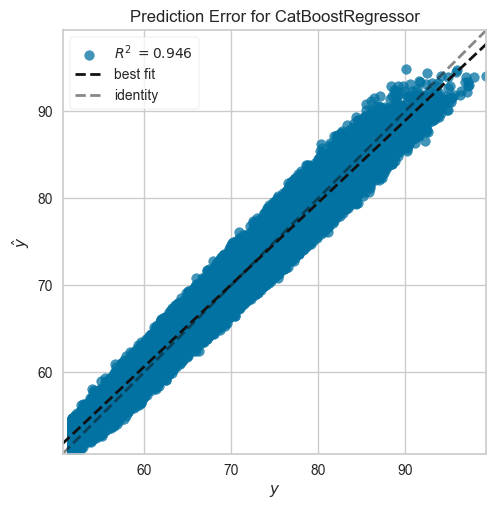

In [23]:
preprocessing_exp.plot_model(
    tuned_best_model,
    plot="error"
)

The prediction error plot shows that the predicted values are closely concentrated around the identity line, indicating strong agreement between the model predictions and the actual target values. The best-fit line also lies close to the identity line, with an R² of approximately **0.946** shown in the diagnostic plot.

A small deviation can be observed at the extremes. The model tends to slightly overpredict values at the lower end and underpredict values at the higher end. However, the overall spread around the reference line remains relatively narrow, indicating generally consistent prediction performance.

### 8.3 Residual Plot

A residual plot is used to examine the differences between the actual and predicted target values. Ideally, the residuals should be distributed randomly around zero without a clear systematic pattern.

This helps determine whether the tuned CatBoost model exhibits consistent prediction bias across different fitted values and whether the spread of prediction errors changes substantially across the target range.

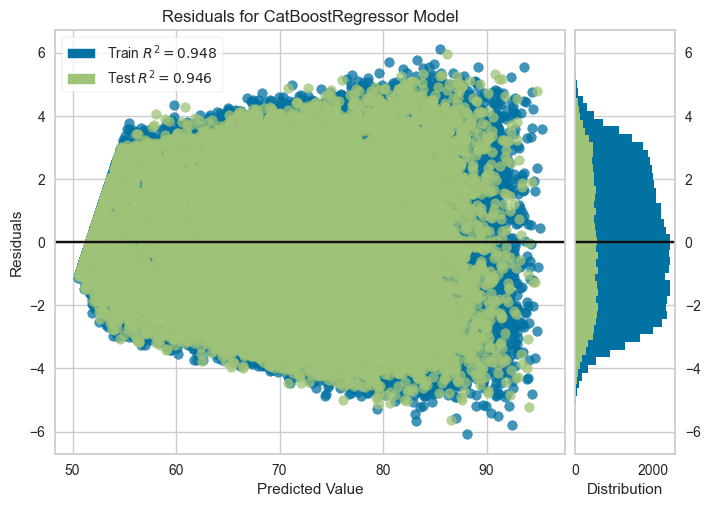

In [24]:
preprocessing_exp.plot_model(
    tuned_best_model,
    plot="residuals"
)

The residual plot shows that the residuals are distributed on both sides of the zero line, with no strong systematic upward or downward pattern. The training and test residuals also overlap substantially, while their R² values are very similar at **0.948** and **0.946** respectively. This suggests that the model behaves consistently across the training and holdout data.

However, the spread of the residuals becomes wider as the predicted value increases. This indicates that prediction errors tend to be more variable for higher target values, which is consistent with the slight underprediction observed for higher values in the prediction error plot. As target transformation is enabled, the residual diagnostic is also displayed on the transformed target scale.

Overall, the residual plot does not indicate a strong systematic bias, although the wider spread at higher predicted values suggests that prediction errors become more variable for higher salary values.

### 8.4 Feature Importance

Feature importance is examined to identify which predictors contribute most strongly to the tuned CatBoost model's salary predictions. This provides additional interpretability and helps determine whether the model is relying on variables that are consistent with the relationships identified during EDA.

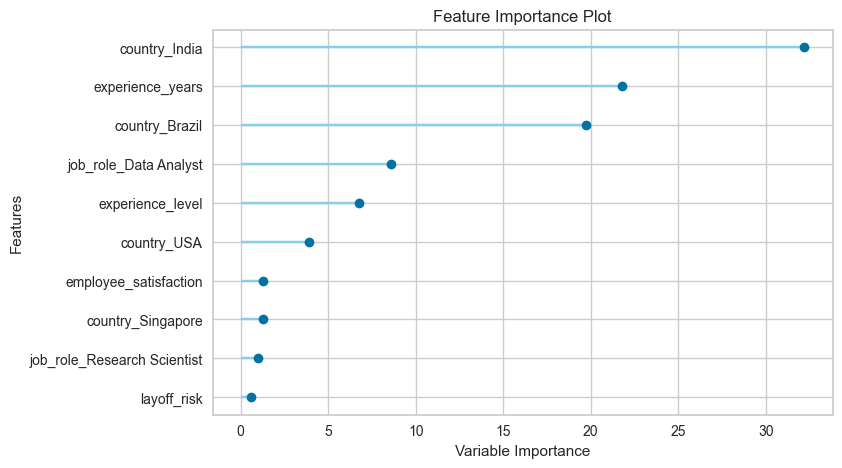

In [25]:
preprocessing_exp.plot_model(
    tuned_best_model,
    plot="feature"
)

The feature importance plot shows that the tuned CatBoost model relies most strongly on geographical, experience-related, and job-role information when predicting salary.

`country_India` has the highest importance, followed by `experience_years` and `country_Brazil`. Other influential predictors include `job_role_Data Analyst`, `experience_level`, and `country_USA`. This is generally consistent with the EDA, which identified country, experience, and job role as important factors associated with salary differences.

`employee_satisfaction` also contributes to the model, while features such as `layoff_risk` have comparatively lower importance among the top ten features shown.

The categorical feature names such as `country_India` represent encoded categories created during preprocessing. Feature importance indicates how much a feature contributes to the model predictions, but it does not indicate whether the feature increases or decreases the predicted salary.

## 9. Final Model Training

Following the cross-validation, hyperparameter tuning, holdout evaluation, and diagnostic analysis, the tuned CatBoost model is selected as the final model.

The model is finalised using PyCaret's `finalize_model()` function. This retrains the complete preprocessing and modelling pipeline using all available development data, including both the training and holdout portions previously created during `setup()`.

The separate unseen dataset remains excluded from this process and will only be used for the final prediction stage.

In [32]:
final_model = preprocessing_exp.finalize_model(
    tuned_best_model
)

final_model

2026/08/21 13:08:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 13:08:48 INFO mlflow.tracking._tracking_service.client: 🏃 View run CatBoost Regressor at: http://127.0.0.1:5000/#/experiments/651957420376816323/runs/0c5d035ca8504fc6859b65f8343136b0.
2026/08/21 13:08:48 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/651957420376816323.


Pipeline(memory=Memory(location=None),
         steps=[('target_transformation',
                 TransformerWrapperWithInverse(transformer=TargetTransformer(estimator=PowerTransformer(standardize=False)))),
                ('numerical_imputer',
                 TransformerWrapper(include=['experience_years',
                                             'interview_rounds', 'year',
                                             'weekly_hours', 'company_rating',
                                             'job_openings',
                                             'hiring_difficulty_score',
                                             'lay...
                                                                    'ai_specialization',
                                                                    'industry',
                                                                    'work_mode'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ('normalize', TransformerWrapper(transformer=MinMaxScaler())),
                ('actual_estimator',
                 CatBoostRegressor(border_count=254, depth=6, iterations=700, l2_leaf_reg=7, learning_rate=0.03, loss_function='RMSE', random_state=42, random_strength=1, task_type='CPU', verbose=False))])

## 10. Final Prediction on Unseen Data

After finalising the tuned CatBoost pipeline using all available development data, the model is applied to the separate unseen dataset that was reserved before model development.

This dataset was not used during cross-validation, hyperparameter tuning, holdout evaluation, or final model training. It therefore provides a final demonstration of how the completed pipeline generates predictions for new job records.

The finalised CatBoost pipeline achieved an RMSE of approximately **$11,155.59** and an MAE of **$8,747.63** on the unseen dataset. The model also achieved an R² of **0.9348**, indicating that it explains approximately 93.48% of the variation in `salary_usd` for records that were not used during model development.

The unseen-data performance is slightly better than the earlier holdout result, where the tuned model achieved an RMSE of approximately **$11,298.15**. This suggests that the finalised model continues to generalise well after being retrained using the full development dataset.

The random prediction sample also shows that many predictions are close to the actual salaries, although the size of the error varies across individual records. Some examples have errors below **$1,000**, while others show larger differences of around **$10,000**, which is consistent with the overall RMSE and MAE results.

Overall, the final unseen evaluation confirms that the completed pipeline maintains strong predictive performance on data that was kept separate from model training, tuning, and holdout evaluation.

In [38]:
# Generate predictions on the unseen dataset
unseen_predictions = preprocessing_exp.predict_model(
    final_model,
    data=unseen_data
)

# Pull final unseen evaluation metrics
unseen_metrics = preprocessing_exp.pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,8747.6280,124447228.6193,11155.5918,0.9348,0.1073,0.0920


In [42]:
prediction_samples = unseen_predictions[
    ["salary_usd", "prediction_label"]
].copy()

prediction_samples.columns = [
    "Actual Salary",
    "Predicted Salary"
]

prediction_samples["Absolute Error"] = (
    prediction_samples["Actual Salary"]
    - prediction_samples["Predicted Salary"]
).abs()

prediction_samples.sample(
    10,
    random_state=cfg.model.random_state
).style.format({
    "Actual Salary": "${:,.2f}",
    "Predicted Salary": "${:,.2f}",
    "Absolute Error": "${:,.2f}"
})

,Actual Salary,Predicted Salary,Absolute Error
38956,"$28,732.00","$29,073.13",$341.13
83603,"$61,462.00","$62,182.69",$720.69
15692,"$84,921.00","$85,526.07",$605.07
35924,"$101,959.00","$103,736.00","$1,777.00"
3785,"$75,970.00","$79,303.81","$3,333.81"
46667,"$77,547.00","$87,759.50","$10,212.50"
5069,"$49,434.00","$59,429.29","$9,995.29"
46598,"$105,038.00","$100,012.29","$5,025.71"
65705,"$61,122.00","$57,206.73","$3,915.27"
19545,"$139,011.00","$143,029.75","$4,018.75"


## 11. Save Final Model Pipeline and Supporting Artifacts

The finalised CatBoost model is saved together with the complete PyCaret preprocessing pipeline. This preserves the preprocessing steps from the selected modelling experiment, including categorical encoding, Min-Max normalisation and target transformation, so that the same transformations are applied automatically when new raw observations are supplied to the model.

The complete pipeline is saved as `final_salary_catboost_pipeline.pkl`. This is the main deployment artifact because it contains both the preprocessing operations and the trained CatBoost model, allowing predictions to be generated without manually recreating the transformations outside PyCaret.

In addition, the transformed development dataset is saved as `global_ai_jobs_preprocessed.csv`. The transformed predictors are obtained from PyCaret using `X_transformed`, while the transformed target is obtained using `y_transformed`. These are combined to preserve the processed representation used during model development.

The separately reserved unseen dataset is also saved as `global_ai_jobs_test.csv`. This retains the target variable and can therefore be used for future evaluation and verification of the final model. A feature-only version, `global_ai_jobs_test_features.csv`, is also created by removing the target and excluded features, providing a sample dataset for testing batch prediction in the deployed application.

Finally, a model input schema is automatically generated and saved as `salary_model_schema.json`. The schema records the features required by the final model, valid categorical and ordinal values, and the minimum, maximum and median values of numerical predictors. This allows the web application to dynamically construct and validate model inputs without hardcoding the feature definitions directly into the application source code.

In [43]:
# Create output folders
models_path = PROJECT_ROOT / "darren" / "models"
processed_path = PROJECT_ROOT / "darren" / "data" / "processed"

models_path.mkdir(parents=True, exist_ok=True)
processed_path.mkdir(parents=True, exist_ok=True)

# 1. Save final CatBoost + complete preprocessing pipeline
final_model_path = models_path / "final_salary_catboost_pipeline"

preprocessing_exp.save_model(
    final_model,
    str(final_model_path)
)

# 2. Save fully preprocessed development dataset
X_processed = preprocessing_exp.get_config("X_transformed").copy()
y_processed = preprocessing_exp.get_config("y_transformed").copy()

# Combine transformed predictors and target
processed_dataset = X_processed.copy()
processed_dataset["salary_usd_transformed"] = y_processed.values

processed_dataset_path = (
    processed_path / "global_ai_jobs_preprocessed.csv"
)

processed_dataset.to_csv(
    processed_dataset_path,
    index=False
)


# Verify saved files
print(
    "Model saved:",
    final_model_path.with_suffix(".pkl")
)

print(
    "Preprocessed dataset saved:",
    processed_dataset_path
)

print(
    "Preprocessed dataset shape:",
    processed_dataset.shape
)

Transformation Pipeline and Model Successfully Saved
Model saved: c:\Users\darre\Documents\GitHub\mlops-assignment\darren\models\final_salary_catboost_pipeline.pkl
Preprocessed dataset saved: c:\Users\darre\Documents\GitHub\mlops-assignment\darren\data\processed\global_ai_jobs_preprocessed.csv
Preprocessed dataset shape: (81000, 68)


In [48]:
# Save reserved unseen/test dataset
test_dataset_path = (
    processed_path / "global_ai_jobs_test.csv"
)

unseen_data.to_csv(
    test_dataset_path,
    index=False
)

# Save feature-only version for future batch prediction
test_features = unseen_data.drop(
    columns=[target] + ignore_features
)

test_features_path = (
    processed_path / "global_ai_jobs_test_features.csv"
)

test_features.to_csv(
    test_features_path,
    index=False
)

print("Test dataset saved:", test_dataset_path)
print("Test features saved:", test_features_path)
print("Test dataset shape:", unseen_data.shape)
print("Test features shape:", test_features.shape)

Test dataset saved: c:\Users\darre\Documents\GitHub\mlops-assignment\darren\data\processed\global_ai_jobs_test.csv
Test features saved: c:\Users\darre\Documents\GitHub\mlops-assignment\darren\data\processed\global_ai_jobs_test_features.csv
Test dataset shape: (9000, 35)
Test features shape: (9000, 31)


In [47]:
import json

# Features actually used by the model
feature_columns = [
    col for col in model_data.columns
    if col not in [target] + ignore_features
]

# Categorical columns
categorical_columns = categorical_features + list(ordinal_features.keys())

schema = {
    "features": feature_columns,

    "categorical": {
        col: sorted(model_data[col].dropna().unique().tolist())
        for col in categorical_features
    },

    "ordinal": ordinal_features,

    "numeric": {}
}

# Automatically obtain numeric ranges/defaults
for col in feature_columns:
    if col not in categorical_columns:
        schema["numeric"][col] = {
            "min": float(model_data[col].min()),
            "max": float(model_data[col].max()),
            "default": float(model_data[col].median())
        }

schema_path = models_path / "salary_model_schema.json"

with open(schema_path, "w") as f:
    json.dump(schema, f, indent=4)

print("Schema saved:", schema_path)

Schema saved: c:\Users\darre\Documents\GitHub\mlops-assignment\darren\models\salary_model_schema.json


## 12. MLflow Model Registration

Experiment tracking was enabled throughout model development using PyCaret built-in MLflow integration. The selected CatBoost model was subsequently registered using the MLflow Model Registry hosted on the local MLflow tracking server.

The registered model provides a centralised and versioned record of the selected model, supporting model lifecycle management and future deployment.

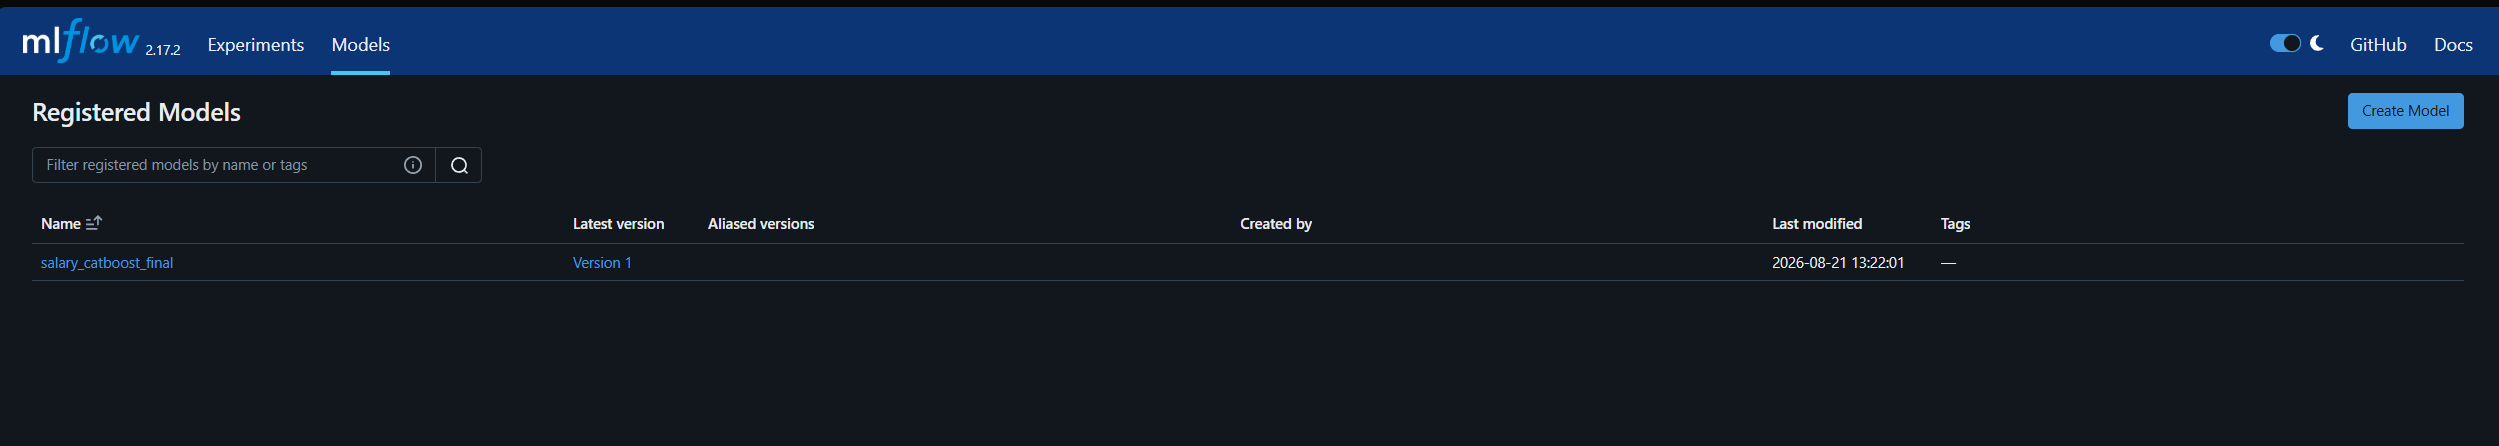